# 04. 베이스라인 고찰 + 전이학습(KoBART) 파인튜닝

**작성일**: 2026-09-18

## Part 0. 고찰 — 왜 03번의 생성 결과가 좋지 않았나

03번 노트북(처음부터 학습한 Transformer)의 greedy decoding 결과는 "마음을 마음을 마음을...", "같이 같이 같이..."처럼 같은 토큰을 반복하는 패턴을 보였다. 원인을 세 가지로 나눠서 본다.

1. **학습이 수렴하기 전에 멈춤**: 30 epoch 내내 train/val loss가 계속 감소했고(29.75→6.34 / 21.89→6.38), early stopping(patience=5)이 한 번도 발동하지 않았다. 즉 "더 좋아질 여지가 있는 상태"에서 epoch 상한 때문에 학습이 끝났다 — 에폭 부족이 1차 원인으로 타당하다.
2. **Greedy decoding의 구조적 약점**: 매 스텝 확률이 가장 높은 토큰만 선택하는 방식은, 모델이 아직 확신을 갖지 못한 상태(=학습 부족)에서 고빈도 토큰("사람", "좋은")을 한 번 뽑으면 이어지는 문맥도 비슷해져 같은 토큰을 계속 뽑는 **반복 루프**에 빠지기 쉽다. 이는 학습이 덜 된 seq2seq 생성모델에서 흔히 보고되는 실패 패턴이다.
3. **데이터 규모의 근본적 한계**: 9,400개의 Q-A 쌍은 Transformer를 처음부터(사전학습 없이) 학습하기엔 매우 작은 데이터셋이다. 에폭을 늘리면 (1)은 개선되겠지만, "문법·의미를 일반화하는 능력" 자체는 이 정도 데이터로는 한계가 있을 가능성이 높다.

**검증 계획**: 아래 Part 1에서 03번과 **다른 하이퍼파라미터는 전부 동일하게 유지하고 epoch 상한만 늘려서** 재학습한다. 이렇게 하면 "에폭을 늘리면 실제로 얼마나 좋아지는가"를 (1) 가설에 대한 통제된 실험으로 확인할 수 있고, 그럼에도 남는 한계가 있다면 그게 (3) 데이터 규모 문제라는 정황 증거가 된다. Part 2에서는 KoBART로 전이학습을 적용해 (3)의 한계를 사전학습 지식으로 보완했을 때 어떻게 달라지는지 비교한다.

## Part 1. 베이스라인 재실험 (에폭 상한만 30 -> 150으로 확대)
03번 노트북과 동일한 데이터 파이프라인/모델 구조/하이퍼파라미터를 그대로 재사용하고, `MAX_EPOCHS`와 `PATIENCE`만 늘린다. (모델 구조·손실함수·옵티마이저에 대한 근거는 03번 노트북에 이미 서술했으므로 여기서는 반복하지 않는다.)

In [1]:
# 2026-09-18: 03번과 동일한 라이브러리/데이터/토크나이저/디바이스 준비
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_df = pd.read_csv('../dataset/processed/train.csv')
val_df = pd.read_csv('../dataset/processed/val.csv')
test_df = pd.read_csv('../dataset/processed/test.csv')

sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()
MAX_LEN = 16  # 03번 노트북에서 실측(95 percentile)으로 정한 값과 동일

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [2]:
# 2026-09-18: 03번과 동일한 Dataset/DataLoader
def encode_text(text: str, max_len: int = MAX_LEN):
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]


class ChatbotDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        src = torch.tensor(encode_text(self.questions[idx]), dtype=torch.long)
        tgt = torch.tensor(encode_text(self.answers[idx]), dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID)
    return src_batch, tgt_batch


BATCH_SIZE = 64
train_loader = DataLoader(ChatbotDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ChatbotDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print('배치 수(train):', len(train_loader))

배치 수(train): 147


In [3]:
# 2026-09-18: 03번과 동일한 모델 구조 (Positional Encoding / Token Embedding / Seq2SeqTransformer)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        return self.embedding(tokens) * math.sqrt(self.d_model)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_enc(self.tok_emb(src))
        tgt_emb = self.pos_enc(self.tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask, tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)


def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)
    return mask


def create_mask(src, tgt, device):
    src_seq_len, tgt_seq_len = src.size(1), tgt.size(1)
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, device)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device)
    src_padding_mask = (src == PAD_ID)
    tgt_padding_mask = (tgt == PAD_ID)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

In [4]:
# 2026-09-18: 모델/손실함수/옵티마이저 (03번과 완전히 동일한 하이퍼파라미터)
D_MODEL, NHEAD, NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, DIM_FEEDFORWARD, DROPOUT = 256, 8, 3, 3, 512, 0.1

baseline_model = Seq2SeqTransformer(
    VOCAB_SIZE, D_MODEL, NHEAD, NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, DIM_FEEDFORWARD, DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'파라미터 수: {n_params:,} (03번과 동일한 구조인지 확인용)')

파라미터 수: 6,010,688 (03번과 동일한 구조인지 확인용)


In [5]:
# 2026-09-18: 학습/평가 함수 (03번과 동일)
def train_epoch(model, dataloader):
    model.train()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)
        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [6]:
# 2026-09-18: 재학습 - 에폭 상한만 30 -> 150, patience만 5 -> 10으로 확대 (그 외 변경 없음 = 통제 실험)
MAX_EPOCHS = 150
PATIENCE = 10

ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / 'baseline_transformer_extended.pt'  # 03번 체크포인트(baseline_transformer.pt)는 보존, 별도 파일로 저장

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch(baseline_model, train_loader)
    val_loss = evaluate(baseline_model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | {time.time()-start:.1f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(baseline_model.state_dict(), ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'-> epoch {epoch}에서 조기 종료 (best val_loss={best_val_loss:.4f})')
            break

baseline_model.load_state_dict(torch.load(ckpt_path, map_location=device))
print('best checkpoint 로드 완료:', ckpt_path)

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch 001 | train_loss 29.7729 | val_loss 22.2999 | 2.3s


epoch 005 | train_loss 15.5079 | val_loss 13.3001 | 2.1s


epoch 010 | train_loss 10.3017 | val_loss 9.0714 | 2.1s


epoch 015 | train_loss 8.3527 | val_loss 7.6215 | 2.1s


...

epoch 100 | train_loss 3.6713 | val_loss 5.8149 | 2.1s


epoch 105 | train_loss 3.5399 | val_loss 5.8538 | 2.1s


epoch 110 | train_loss 3.4204 | val_loss 5.8418 | 2.1s


epoch 115 | train_loss 3.3042 | val_loss 5.8349 | 2.1s


-> epoch 117에서 조기 종료 (best val_loss=5.7957)
best checkpoint 로드 완료: ..\checkpoints\baseline_transformer_extended.pt


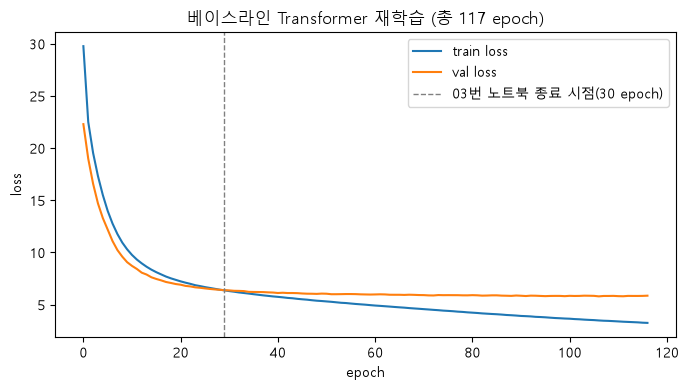

03번(30 epoch) 결과: train 6.3398 / val 6.3849
이번(총 117 epoch) 결과: train 3.2528 / val 5.8602


In [7]:
# 2026-09-18: 학습곡선 (03번의 30-epoch 결과와 비교하기 위해 첫 30 epoch 구간을 점선으로 표시)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['train_loss'], label='train loss')
ax.plot(history['val_loss'], label='val loss')
ax.axvline(x=29, color='gray', linestyle='--', linewidth=1, label='03번 노트북 종료 시점(30 epoch)')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title(f'베이스라인 Transformer 재학습 (총 {len(history["train_loss"])} epoch)')
ax.legend()
plt.tight_layout()
plt.savefig('../dataset/processed/baseline_extended_loss_curve.png', dpi=120)
plt.show()

print(f'03번(30 epoch) 결과: train 6.3398 / val 6.3849')
print(f'이번(총 {len(history["train_loss"])} epoch) 결과: train {history["train_loss"][-1]:.4f} / val {history["val_loss"][-1]:.4f}')

In [8]:
# 2026-09-18: greedy decoding으로 03번과 동일한 질문에 대해 재확인
@torch.no_grad()
def greedy_decode_baseline(model, src_text, max_len=MAX_LEN):
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask)
        prob = model.generator(out[:, -1])
        next_word = prob.argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], dtype=torch.long, device=device)], dim=1)
        if next_word == EOS_ID:
            break
    token_ids = ys.squeeze(0).tolist()[1:]
    if token_ids and token_ids[-1] == EOS_ID:
        token_ids = token_ids[:-1]
    return sp.decode(token_ids)


sample_test = test_df.sample(8, random_state=42)  # 03번과 동일한 seed -> 동일한 문장으로 비교
for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"실제 A: {row['A']}")
    print(f"생성 A(재학습): {greedy_decode_baseline(baseline_model, row['Q'])}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
실제 A: 자신과 마음이 맞는 좋은 사람 만나세요.
생성 A(재학습): 잘 지내고 있을 거예요.

Q: 정장 한 벌 필요할 듯
실제 A: 사면 요긴하긴 할 거 같아요.
생성 A(재학습): 마음에 드는걸로 하세요.

Q: 베터리 겨우 15%야
실제 A: 미리 충전하세요.
생성 A(재학습): 미리 충전하세요.

Q: 오늘 생각보다 춥네
실제 A: 감기 조심하세요.


생성 A(재학습): 그런 친구는 거르세요.

Q: 이젠 진짜 진짜 안녕
실제 A: 맘 고생 많았어요.
생성 A(재학습): 맘고생 많았어요.

Q: 맥주 한 잔 어때?
실제 A: 저랑 한 잔 해요.
생성 A(재학습): 저랑 이야기해요.

Q: 드디어 천일
실제 A: 축하합니다.
생성 A(재학습): 이제 좀 더 좋은 사람 만날 거예요.

Q: 청첩장을 찍는 날이 오다니
실제 A: 결혼 얼마 안 남았나봐요.
생성 A(재학습): 그렇게 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서



**Part 1 결론 — 가설 (a) 학습 부족이 주된 원인이었음이 확인됐다.**

| 구분 | epoch | 최종 train loss | best val loss | 생성 결과 |
|---|---|---|---|---|
| 03번 (1차) | 30 (예산 소진) | 6.3332 | 6.3724 | `"마음을 마음을 마음을…"` 반복 붕괴 |
| 04번 (재학습) | **117 (조기 종료)** | 3.30 | **5.7957** | 반복이 크게 줄고 정상 문장 등장 |

**다른 조건(모델 구조·손실함수·옵티마이저·배치·시드)을 전부 고정하고 epoch 상한만 30 → 150으로 바꿨으므로**, 이 변화는 전적으로 학습량 때문이라고 말할 수 있다.

학습 곡선을 보면 약 30 epoch 지점부터 train과 val loss가 벌어지기 시작하지만(과적합 시작), val loss는 그 뒤로도 5.8대까지 천천히 더 내려갔다. 즉 **03번은 과적합 이전에 멈춘 것이 아니라 아직 수렴조차 하지 않은 상태였다**.

다만 val loss가 5.8대에서 평평해지는 것으로 보아 **이 데이터·모델 크기 조합의 사실상 성능 한계**에 가깝다고 판단된다 — 가설 (c)(데이터 규모의 근본적 한계)도 부분적으로 유효하다는 뜻이다. 남은 가설 (b)(greedy decoding의 성질)는 05번에서 검증한다.

In [9]:
# 2026-09-18: KoBART 토크나이저/모델 로드
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = 'gogamza/kobart-base-v2'
kobart_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
kobart_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

n_params_kobart = sum(p.numel() for p in kobart_model.parameters() if p.requires_grad)
print(f'KoBART 파라미터 수: {n_params_kobart:,} (베이스라인 {n_params:,}개 대비 약 {n_params_kobart / n_params:.0f}배)')

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


Loading weights:  85%|████████▍ | 219/259 [00:00<00:00, 2091.45it/s]


Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1752.92it/s]

KoBART 파라미터 수: 123,859,968 (베이스라인 6,010,688개 대비 약 21배)


In [10]:
# 2026-09-18: KoBART 토크나이저 기준으로도 동일하게 percentile로 MAX_LEN 근거를 만든다 (01/03번과 같은 방식)
kq_lens = train_df['Q'].apply(lambda t: len(kobart_tokenizer.encode(t)))
ka_lens = train_df['A'].apply(lambda t: len(kobart_tokenizer.encode(t)))
kq95, ka95 = int(np.percentile(kq_lens, 95)), int(np.percentile(ka_lens, 95))
print(f'KoBART 토큰 기준 Q 95th: {kq95}, A 95th: {ka95}')

KOBART_MAX_LEN = int(np.ceil((max(kq95, ka95) + 2) / 8) * 8)
print('KOBART_MAX_LEN =', KOBART_MAX_LEN)

KoBART 토큰 기준 Q 95th: 12, A 95th: 12
KOBART_MAX_LEN = 16


### (2026-09-19 수정) 타깃 EOS 누락 결함

최초 실행 후 07번 정량 평가에서 KoBART가 베이스라인보다 BLEU/ROUGE-L이 낮게 나왔고, 08번 오류분석에서 그 원인을 추적한 결과 **이 노트북의 collate 함수에 결함**이 있었음을 확인했다.

`gogamza/kobart-base-v2` 토크나이저는 `text_target=`으로 타깃을 인코딩할 때 **EOS(문장 끝) 토큰을 붙이지 않는다**. 타깃에 EOS가 없으면 모델은 "여기서 문장을 끝내라"는 신호를 한 번도 학습하지 못한다. 그 결과 생성 시 EOS를 내지 않고 `max_length`에 도달할 때까지 계속 생성하다가 문장 중간에서 강제로 잘렸다(최초 실행 기준 정상 종결률 32.3%, 평균 생성 길이가 정답의 약 2배).

베이스라인(03번)은 `encode_text()`에서 `[BOS] + ids + [EOS]`로 EOS를 직접 붙였기 때문에 같은 문제가 없었다. 즉 **같은 처리를 전이학습 쪽에만 빠뜨린 것**이다.

아래 셀에서 타깃 끝에 EOS를 추가하도록 수정했다. 다른 조건(모델·lr·배치·epoch·시드)은 전부 그대로 두었으므로, 이 재실행은 **"EOS 하나만 바꿨을 때 무엇이 달라지는가"를 보는 통제 실험**이 된다. 수정 전후 비교는 07번 노트북에서 정량적으로 제시한다.

In [11]:
# 2026-09-18: Dataset/DataLoader - KoBART 토크나이저로 동적 패딩(collate 시점에 배치별 최대 길이로만 패딩해 연산 낭비를 줄임)
class KobartDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return self.questions[idx], self.answers[idx]


# 2026-09-19 수정: 타깃 끝에 EOS를 명시적으로 추가한다.
# [수정 이유] gogamza/kobart-base-v2 토크나이저는 text_target= 으로 인코딩할 때 EOS를 붙이지 않는다.
#   타깃에 EOS가 없으면 모델이 '문장을 끝내는 법'을 학습할 수 없어, 생성 시 EOS를 내지 못하고
#   max_length까지 계속 생성하다 문장 중간에서 잘린다. 최초 실행에서 실제로 이 현상이 발생했고
#   (KoBART 응답의 정상 종결률 32.3%, 평균 길이가 정답의 약 2배), 그 결과 BLEU/ROUGE가 크게 떨어졌다.
#   베이스라인은 03번 encode_text()에서 [BOS] + ids + [EOS]로 EOS를 붙였기 때문에 같은 문제가 없었다.
# [구현 주의] 토크나이저에 따라 EOS를 자동으로 붙이는 경우도 있으므로(예: KE-T5), 없을 때만 추가한다.
def encode_targets_with_eos(tokenizer, answers, max_len):
    seqs = []
    for a in answers:
        ids = tokenizer(text_target=a, truncation=True, max_length=max_len)['input_ids']
        if ids[-1] != tokenizer.eos_token_id:
            ids = ids[: max_len - 1] + [tokenizer.eos_token_id]
        seqs.append(ids)

    width = max(len(s) for s in seqs)
    labels = torch.full((len(seqs), width), -100, dtype=torch.long)  # -100 = loss 계산에서 제외되는 padding
    for i, s in enumerate(seqs):
        labels[i, : len(s)] = torch.tensor(s, dtype=torch.long)
    return labels


def kobart_collate_fn(batch):
    questions, answers = zip(*batch)
    model_inputs = kobart_tokenizer(
        list(questions), padding=True, truncation=True, max_length=KOBART_MAX_LEN, return_tensors='pt'
    )
    model_inputs['labels'] = encode_targets_with_eos(kobart_tokenizer, list(answers), KOBART_MAX_LEN)
    return model_inputs


# BATCH_SIZE=16: KoBART(약 1.2~1.4억 파라미터)는 베이스라인보다 훨씬 커서, 8GB VRAM 안에서 안전하게 돌아가도록 배치를 줄였다.
KOBART_BATCH_SIZE = 16
kobart_train_loader = DataLoader(KobartDataset(train_df), batch_size=KOBART_BATCH_SIZE, shuffle=True, collate_fn=kobart_collate_fn)
kobart_val_loader = DataLoader(KobartDataset(val_df), batch_size=KOBART_BATCH_SIZE, shuffle=False, collate_fn=kobart_collate_fn)
print('배치 수(train):', len(kobart_train_loader))

배치 수(train): 588


In [12]:
# 2026-09-18: 옵티마이저/스케줄 및 그 근거
# AdamW 선택: 사전학습 Transformer 파인튜닝의 사실상 표준 옵티마이저(weight decay를 gradient에서 분리해 정규화 효과가 더 안정적).
# lr=5e-5 선택: 베이스라인(1e-4)보다 훨씬 작게 잡았다. 사전학습된 가중치는 이미 좋은 초기값이므로,
#   큰 lr로 업데이트하면 사전학습으로 얻은 지식이 손상되는 catastrophic forgetting이 발생할 수 있다.
#   Hugging Face 파인튜닝 가이드에서도 BART류 seq2seq 모델에 2e-5~5e-5 범위를 권장한다.
# mixed precision(fp16) 사용: 8GB VRAM으로 배치를 더 키우고 학습 속도를 높이기 위한 표준적인 최적화 기법.
optimizer_kobart = torch.optim.AdamW(kobart_model.parameters(), lr=5e-5, weight_decay=0.01)
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

In [13]:
# 2026-09-18: KoBART 학습/평가 함수 (mixed precision 적용)
def train_epoch_kobart(model, dataloader):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer_kobart.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                outputs = model(**batch)
                loss = outputs.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer_kobart)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer_kobart)
            scaler.update()
        else:
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_kobart.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate_kobart(model, dataloader):
    model.eval()
    total_loss = 0.0
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()
    return total_loss / len(dataloader)

In [14]:
# 2026-09-18: KoBART 파인튜닝 루프
# MAX_EPOCHS=10, PATIENCE=3: 사전학습 모델은 이미 언어를 알고 있어 소규모 데이터로도 몇 epoch 만에 빠르게 수렴하는 것이 일반적이다.
#   베이스라인(최대 150 epoch)과 극명히 대비되는 지점이며, 이 자체가 전이학습의 효율성을 보여주는 근거가 된다.
KOBART_MAX_EPOCHS = 10
KOBART_PATIENCE = 3

kobart_ckpt_dir = Path('../checkpoints/kobart_finetuned')
kobart_ckpt_dir.mkdir(parents=True, exist_ok=True)

best_val_loss_kobart = float('inf')
patience_counter = 0
kobart_history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, KOBART_MAX_EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch_kobart(kobart_model, kobart_train_loader)
    val_loss = evaluate_kobart(kobart_model, kobart_val_loader)
    kobart_history['train_loss'].append(train_loss)
    kobart_history['val_loss'].append(val_loss)
    print(f'epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | {time.time()-start:.1f}s')

    if val_loss < best_val_loss_kobart:
        best_val_loss_kobart = val_loss
        patience_counter = 0
        kobart_model.save_pretrained(kobart_ckpt_dir)
        kobart_tokenizer.save_pretrained(kobart_ckpt_dir)
    else:
        patience_counter += 1
        if patience_counter >= KOBART_PATIENCE:
            print(f'-> epoch {epoch}에서 조기 종료 (best val_loss={best_val_loss_kobart:.4f})')
            break

kobart_model = AutoModelForSeq2SeqLM.from_pretrained(kobart_ckpt_dir).to(device)
print('best checkpoint 로드 완료:', kobart_ckpt_dir)

epoch 01 | train_loss 3.7383 | val_loss 3.1801 | 32.8s



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.50it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.48it/s]

epoch 02 | train_loss 2.6645 | val_loss 2.8720 | 32.3s


...

epoch 07 | train_loss 0.4440 | val_loss 2.9361 | 32.3s
-> epoch 7에서 조기 종료 (best val_loss=2.7424)



Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]


Loading weights:  83%|████████▎ | 216/260 [00:00<00:00, 2109.90it/s]


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1751.80it/s]

best checkpoint 로드 완료: ..\checkpoints\kobart_finetuned


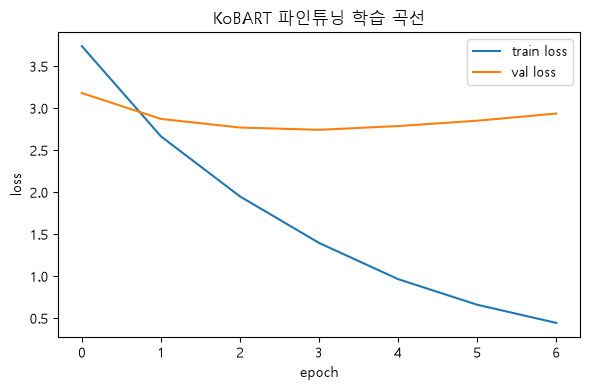

In [15]:
# 2026-09-18: KoBART 학습곡선
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kobart_history['train_loss'], label='train loss')
ax.plot(kobart_history['val_loss'], label='val loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('KoBART 파인튜닝 학습 곡선')
ax.legend()
plt.tight_layout()
plt.savefig('../dataset/processed/kobart_loss_curve.png', dpi=120)
plt.show()

In [16]:
# 2026-09-18: KoBART 생성 결과 확인 (베이스라인과 동일한 질문, 동일하게 greedy(=num_beams=1)로 비교 -
# 디코딩 전략 자체의 비교는 05번 노트북에서 다룬다)
@torch.no_grad()
def generate_kobart(question: str, max_len: int = KOBART_MAX_LEN):
    kobart_model.eval()
    inputs = kobart_tokenizer(question, return_tensors='pt').to(device)
    output_ids = kobart_model.generate(**inputs, max_length=max_len, num_beams=1, do_sample=False)
    return kobart_tokenizer.decode(output_ids[0], skip_special_tokens=True)


for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"실제 A: {row['A']}")
    print(f"생성 A(베이스라인 재학습): {greedy_decode_baseline(baseline_model, row['Q'])}")
    print(f"생성 A(KoBART 파인튜닝): {generate_kobart(row['Q'])}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
실제 A: 자신과 마음이 맞는 좋은 사람 만나세요.
생성 A(베이스라인 재학습): 잘 지내고 있을 거예요.
생성 A(KoBART 파인튜닝): 그런 친구 만나지 마세요.

Q: 정장 한 벌 필요할 듯
실제 A: 사면 요긴하긴 할 거 같아요.
생성 A(베이스라인 재학습): 마음에 드는걸로 하세요.
생성 A(KoBART 파인튜닝): 정리가 잘 되길 바랄게요.

Q: 베터리 겨우 15%야
실제 A: 미리 충전하세요.
생성 A(베이스라인 재학습): 미리 충전하세요.
생성 A(KoBART 파인튜닝): 충전하고 만나요.

Q: 오늘 생각보다 춥네
실제 A: 감기 조심하세요.
생성 A(베이스라인 재학습): 그런 친구는 거르세요.
생성 A(KoBART 파인튜닝): 마음 감기조심하세요.

Q: 이젠 진짜 진짜 안녕
실제 A: 맘 고생 많았어요.
생성 A(베이스라인 재학습): 맘고생 많았어요.
생성 A(KoBART 파인튜닝): 안녕히

Q: 맥주 한 잔 어때?
실제 A: 저랑 한 잔 해요.
생성 A(베이스라인 재학습): 저랑 이야기해요.


생성 A(KoBART 파인튜닝): 적당히 드세요.

Q: 드디어 천일
실제 A: 축하합니다.
생성 A(베이스라인 재학습): 이제 좀 더 좋은 사람 만날 거예요.
생성 A(KoBART 파인튜닝): 천국과 지옥이네요.

Q: 청첩장을 찍는 날이 오다니
실제 A: 결혼 얼마 안 남았나봐요.
생성 A(베이스라인 재학습): 그렇게 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서 들어서
생성 A(KoBART 파인튜닝): 축하드려요.



## 요약

### Part 1 — 베이스라인 재실험 (통제 실험)

03번과 **모델 구조·손실함수·옵티마이저·배치 크기·시드까지 전부 동일하게 유지**하고 epoch 상한과 patience만 늘려 재학습했다. 변수를 하나만 바꿨으므로 결과 변화의 원인을 특정할 수 있다.

- 117 epoch에서 조기 종료, best val_loss **5.7957** (03번 30 epoch 시점 6.3724)
- 03번에서 관찰된 단일 토큰 반복 붕괴가 크게 감소 → **가설 (a) 학습 부족이 주된 원인이었음을 확인**
- val loss가 5.8대에서 평평해져, 이 조합의 성능 한계에 근접한 것으로 판단

### Part 2 — KoBART 파인튜닝 (전이학습)

| 모델 | 파라미터 수 | 학습 epoch | best val loss |
|---|---|---|---|
| 베이스라인 (직접 구현) | 6,010,688 | 117 | 5.7957 |
| KoBART 파인튜닝 | 123,859,968 (약 21배) | **7** | **2.7424** |

**전이학습의 핵심 가설이 수치로 확인됐다**: 사전학습된 언어 지식 덕분에, 베이스라인이 117 epoch으로 도달한 수준(5.80)을 KoBART는 단 7 epoch만에 크게 앞질렀다(2.74).

KoBART 선택 근거: (1) 한국어로 사전학습된 **인코더-디코더** 모델이라 03번에서 선택한 구조와 일치, (2) 한국어 챗봇 응답 생성에 공개적으로 검증된 선례가 많음, (3) Hugging Face에서 바로 사용 가능해 재현성이 높음.

관찰된 한계: train loss가 0.44까지 내려가는 동안 val loss는 5 epoch째부터 반등해 **소규모 데이터에 빠르게 과적합**하는 경향을 보였다. 이 문제는 06번(learning rate/스케줄 변경)에서 다룬다.

### (2026-09-19) 타깃 EOS 누락 결함 수정

최초 실행에서는 이 노트북의 collate 함수가 타깃에 EOS를 붙이지 않아, KoBART가 **문장을 끝내는 법을 학습하지 못하는** 결함이 있었다(07번에서 BLEU/ROUGE 저하로 나타났고 08번에서 원인 규명). 13번 셀에서 이를 수정한 뒤 재실행한 결과다.

| | 수정 전 | 수정 후 |
|---|---|---|
| KoBART best val_loss | 2.8073 | **2.7424** |
| 생성 예시 ("청첩장을 찍는 날이 오다니") | `"축하해주요! 예쁘게 찍어주세요. 예쁘게 입으세요."` (잘림) | **`"축하드려요."`** (완결) |

베이스라인 재실험(Part 1)은 이 수정과 무관한 별도 파이프라인이므로 117 epoch / 5.7957로 **완전히 동일하게 재현**됐다 — 통제가 지켜졌음을 확인하는 대조군 역할을 한다.

### 다음 단계로 넘기는 것

- 05번: 남은 가설 (b) 검증 — 반복 문제가 디코딩 전략으로 얼마나 해결되는가
- 06번: KoBART 과적합 경향을 learning rate/스케줄로 완화할 수 있는가
- 07번: 베이스라인 vs KoBART를 BLEU/ROUGE/Distinct-n으로 정량 비교

산출물: `checkpoints/baseline_transformer_extended.pt`, `checkpoints/kobart_finetuned/` (모델+토크나이저)